# Notebook 08 — XAI: Preference-Selective Activation Analysis

**Hipótesis (del paper):** el hypernetwork desarrolla, durante el entrenamiento, **patrones de activación distintos** para preferencias extremas $r=(1,0)$ (maximizar cobertura) y $r=(0,1)$ (minimizar costo). Si es así, distintas preferencias activan subconjuntos estructuralmente diferentes de neuronas internas — evidencia de especialización interna.

**Métricas (Sección 4.3.2 del paper):**
- **Selectivity score** por neurona: $s_n = |a_n^{(1,0)} - a_n^{(0,1)}|$
- **Cosine similarity** entre los vectores de activación completos a nivel de capa
- **Control baseline**: mismo análisis aplicado al modelo *sin entrenar* (inicialización aleatoria)

**Protocolo:** se capturan las activaciones intermedias de las dos capas ocultas del `ray_mlp` bajo ambas preferencias extremas, para el modelo entrenado y el no entrenado.

In [1]:
import sys, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch_geometric.nn import MessagePassing

ROOT     = Path('..')
CKPT_DIR = ROOT / 'checkpoints_VF'
IMG_DIR  = ROOT / 'images_VF_v2'
IMG_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cpu')
print(f'device: {DEVICE}')

device: cpu


## Arquitectura del modelo (copia de nb06)

In [2]:
class MeanAggregator(MessagePassing):
    def __init__(self):            super().__init__(aggr='mean')
    def forward(self, x, ei, N):  return self.propagate(ei, x=x, size=(N, N))
    def message(self, x_j):       return x_j


class HyperNetwork(nn.Module):
    def __init__(self, ray_hidden=100, gnn_hidden=64, in_channels=3):
        super().__init__()
        self.gnn_hidden = gnn_hidden; self.in_channels = in_channels
        h, c = gnn_hidden, in_channels
        self.ray_mlp = nn.Sequential(
            nn.Linear(2, ray_hidden), nn.ReLU(),
            nn.Linear(ray_hidden, ray_hidden), nn.ReLU(),
        )
        self.c1_ll_w = nn.Linear(ray_hidden, h * c)
        self.c1_ll_b = nn.Linear(ray_hidden, h)
        self.c1_lr_w = nn.Linear(ray_hidden, h * c)
        self.c2_ll_w = nn.Linear(ray_hidden, h * h)
        self.c2_ll_b = nn.Linear(ray_hidden, h)
        self.c2_lr_w = nn.Linear(ray_hidden, h * h)
        self.fin_w   = nn.Linear(ray_hidden, h)
        self.fin_b   = nn.Linear(ray_hidden, 1)

    def forward(self, r):
        feat = self.ray_mlp(r)
        h, c, B = self.gnn_hidden, self.in_channels, r.size(0)
        return {
            'c1_ll_w': self.c1_ll_w(feat).view(B, h, c),
            'c1_ll_b': self.c1_ll_b(feat),
            'c1_lr_w': self.c1_lr_w(feat).view(B, h, c),
            'c2_ll_w': self.c2_ll_w(feat).view(B, h, h),
            'c2_ll_b': self.c2_ll_b(feat),
            'c2_lr_w': self.c2_lr_w(feat).view(B, h, h),
            'fin_w':   self.fin_w(feat).view(B, 1, h),
            'fin_b':   self.fin_b(feat).view(B, 1),
        }


class PHNGraphSAGE(nn.Module):
    def __init__(self, hidden=64, dropout=0.4):
        super().__init__()
        self.agg     = MeanAggregator()
        self.bn1     = nn.BatchNorm1d(hidden)
        self.bn2     = nn.BatchNorm1d(hidden)
        self.dropout = dropout

    def _sage(self, x, ei, ll_w, ll_b, lr_w, N):
        agg = self.agg(x, ei, N)
        return F.linear(agg, ll_w, ll_b) + F.linear(x, lr_w)

    def forward(self, x, ei, w):
        N = x.size(0)
        h = self._sage(x, ei, w['c1_ll_w'], w['c1_ll_b'], w['c1_lr_w'], N)
        h = F.relu(self.bn1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self._sage(h, ei, w['c2_ll_w'], w['c2_ll_b'], w['c2_lr_w'], N)
        h = F.relu(self.bn2(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return torch.sigmoid(F.linear(h, w['fin_w'], w['fin_b'])).squeeze(-1)


class PHNModel(nn.Module):
    def __init__(self, in_channels=3, gnn_hidden=64, ray_hidden=100, dropout=0.4):
        super().__init__()
        self.hnet = HyperNetwork(ray_hidden, gnn_hidden, in_channels)
        self.gnn  = PHNGraphSAGE(gnn_hidden, dropout)

    def forward(self, batch):
        r = batch.r.view(batch.num_graphs, 2)
        b = batch.batch
        weights = self.hnet(r)
        outputs, offset = [], 0
        for i in range(batch.num_graphs):
            mask = (b == i)
            x_i  = batch.x[mask]
            N_i  = x_i.size(0)
            e_m  = mask[batch.edge_index[0]]
            ei_i = batch.edge_index[:, e_m] - offset
            w_i  = {k: v[i] for k, v in weights.items()}
            outputs.append(self.gnn(x_i, ei_i, w_i))
            offset += N_i
        return torch.cat(outputs)

print('✓ Clases definidas')

✓ Clases definidas


## Cargar modelo entrenado + crear control no entrenado

El **modelo no entrenado** (misma arquitectura, pesos inicializados aleatoriamente) sirve como baseline estricto: cualquier estructura en el modelo entrenado que *no aparezca* en el no entrenado es consecuencia del aprendizaje, no de la inicialización.

In [3]:
torch.manual_seed(42)  # reproducibility of the control

ckpt = torch.load(CKPT_DIR / 'best_model_kaggle_VF_v2.pt', map_location=DEVICE, weights_only=False)
cfg  = ckpt['config']

trained_model = PHNModel(**cfg).to(DEVICE)
trained_model.load_state_dict(ckpt['model'])
trained_model.eval()

# Control: same architecture, random weights (no checkpoint loaded)
untrained_model = PHNModel(**cfg).to(DEVICE)
untrained_model.eval()

print(f'Trained model loaded (epoch {ckpt["epoch"]}, val_F1={ckpt["val_f1"]:.3f})')
print(f'ray_mlp: {trained_model.hnet.ray_mlp}')
print(f'\nLayer h1 → Linear(2,100) + ReLU   →  activation ∈ ℝ^100')
print(f'Layer h2 → Linear(100,100) + ReLU →  activation ∈ ℝ^100')

Trained model loaded (epoch 9, val_F1=0.732)
ray_mlp: Sequential(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
)

Layer h1 → Linear(2,100) + ReLU   →  activation ∈ ℝ^100
Layer h2 → Linear(100,100) + ReLU →  activation ∈ ℝ^100


## Captura de activaciones intermedias

Se usan **forward hooks** en los módulos ReLU del `ray_mlp` para capturar las activaciones post-ReLU de cada capa oculta bajo los dos vectores de preferencia extremos.

In [12]:
# Preferencias extremas según el paper
R_COV  = torch.tensor([[1.0, 0.0]])  # r=(1,0): maximizar cobertura
R_COST = torch.tensor([[0.0, 1.0]])  # r=(0,1): minimizar costo

LAYER_NAMES  = ['h1', 'h2']
LAYER_LABELS = {
    'h1': 'Hidden Layer 1  (Linear(2→100) + ReLU)',
    'h2': 'Hidden Layer 2  (Linear(100→100) + ReLU)',
}


def capture_activations(model, r_tensor):
    """Ejecuta r por el hypernetwork y retorna activaciones post-ReLU de h1 y h2."""
    acts  = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            acts[name] = out.detach().cpu().numpy().flatten()
        return hook

    # ray_mlp[1] = ReLU tras la primera Linear  → h1
    # ray_mlp[3] = ReLU tras la segunda Linear  → h2
    hooks.append(model.hnet.ray_mlp[1].register_forward_hook(make_hook('h1')))
    hooks.append(model.hnet.ray_mlp[3].register_forward_hook(make_hook('h2')))

    with torch.no_grad():
        model.hnet(r_tensor.to(DEVICE))

    for h in hooks:
        h.remove()
    return acts

print('✓ Función de captura definida')

✓ Función de captura definida


## Cómputo del Selectivity Score y Cosine Similarity

In [13]:
xai_results = {}

for label, mdl in [('trained', trained_model), ('no_trained', untrained_model)]:
    a_cov  = capture_activations(mdl, R_COV)
    a_cost = capture_activations(mdl, R_COST)

    scores      = {}
    cosine_sim  = {}
    frac_act    = {}

    for layer in LAYER_NAMES:
        v1 = a_cov[layer]   # activation under r=(1,0)
        v2 = a_cost[layer]  # activation under r=(0,1)

        # Selectivity score (Ecuación del paper)
        scores[layer] = np.abs(v1 - v2)

        # Cosine similarity between full activation vectors
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        cosine_sim[layer] = float(np.dot(v1, v2) / norm) if norm > 1e-12 else 0.0

        # Fraction of active neurons (> 0 post-ReLU) per preference
        frac_act[layer] = {
            'cov':  float((v1 > 0).mean()),
            'cost': float((v2 > 0).mean()),
        }

    xai_results[label] = {
        'a_cov':      a_cov,
        'a_cost':     a_cost,
        'scores':     scores,
        'cosine_sim': cosine_sim,
        'frac_act':   frac_act,
    }

# ── Tabla resumen ──────────────────────────────────────────────────────────────
print(f"{'Model':<14} {'Layer':<4} {'mean(s)':>9} {'max(s)':>9} "
      f"{'CosSim':>8} {'%act_cov':>9} {'%act_cost':>10}")
print('-' * 68)
for label in ('trained', 'no_trained'):
    rec = xai_results[label]
    for layer in LAYER_NAMES:
        s  = rec['scores'][layer]
        cs = rec['cosine_sim'][layer]
        fa = rec['frac_act'][layer]
        print(f"{label:<14} {layer:<4} {s.mean():>9.4f} {s.max():>9.4f} "
              f"{cs:>8.4f} {fa['cov']:>9.2%} {fa['cost']:>10.2%}")

Model          Layer   mean(s)    max(s)   CosSim  %act_cov  %act_cost
--------------------------------------------------------------------
trained        h1      0.1813    1.1211   0.4355    49.00%     42.00%
trained        h2      0.1735    2.0187   0.5619    19.00%     29.00%
no_trained     h1      0.2651    1.1609   0.6110    53.00%     51.00%
no_trained     h2      0.0802    0.3679   0.7249    40.00%     46.00%


## Visualización 1 — Histogramas del Selectivity Score

Distribución de $s_n = |a_n^{(1,0)} - a_n^{(0,1)}|$ sobre las 100 neuronas de cada capa.
- **Cola pesada hacia la derecha** en el modelo entrenado → muchas neuronas especializadas
- **Distribución compacta** en el no entrenado → sin especialización (línea base)

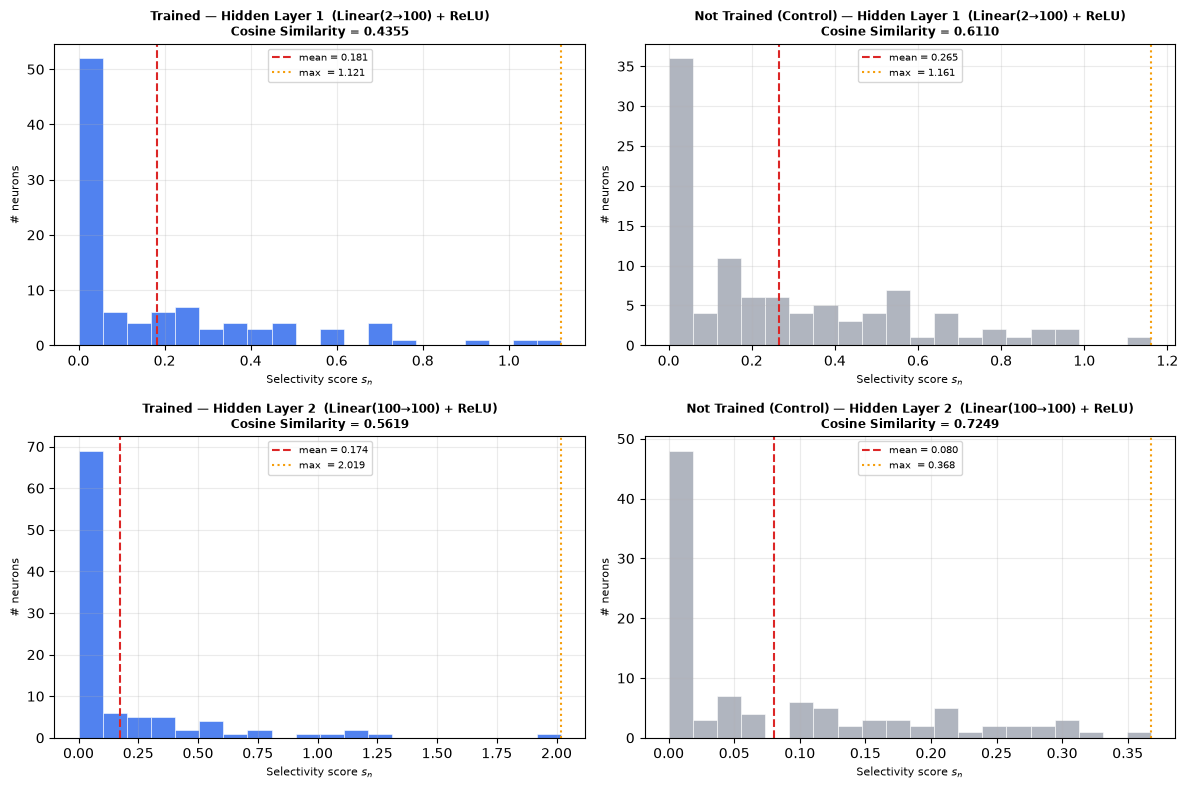

Figure saved to ..\images_VF_v2\xai_histogramas.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

colors = {'trained': '#2563EB', 'no_trained': '#9CA3AF'}
labels_es = {'trained': 'Trained', 'no_trained': 'Not Trained (Control)'}

for row, layer in enumerate(LAYER_NAMES):
    for col, label in enumerate(('trained', 'no_trained')):
        ax  = axes[row, col]
        rec = xai_results[label]
        s   = rec['scores'][layer]
        cs  = rec['cosine_sim'][layer]

        ax.hist(s, bins=20, color=colors[label], alpha=0.8, edgecolor='white', lw=0.5)
        ax.axvline(s.mean(), color='#DC2626', lw=1.5, ls='--',
                   label=f'mean = {s.mean():.3f}')
        ax.axvline(s.max(),  color='#F59E0B', lw=1.5, ls=':',
                   label=f'max  = {s.max():.3f}')

        ax.set_title(f'{labels_es[label]} — {LAYER_LABELS[layer]}\n'
                     f'Cosine Similarity = {cs:.4f}',
                     fontsize=8.5, fontweight='bold')
        ax.set_xlabel('Selectivity score $s_n$', fontsize=8)
        ax.set_ylabel('# neurons', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)

#plt.suptitle('Distribución del Selectivity Score $s_n = |a_n^{(1,0)} - a_n^{(0,1)}|$\n'
#             'por capa oculta — Hypernetwork entrenado vs. control',
#             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_histogramas.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_histogramas.png"}')

## Visualización 2 — Selectivity Score ordenado por neurona (modelo entrenado)

Las neuronas se ordenan de mayor a menor selectividad. Permite identificar cuántas neuronas tienen una especialización alta y cuántas son "neutras" (responden igual a ambas preferencias).

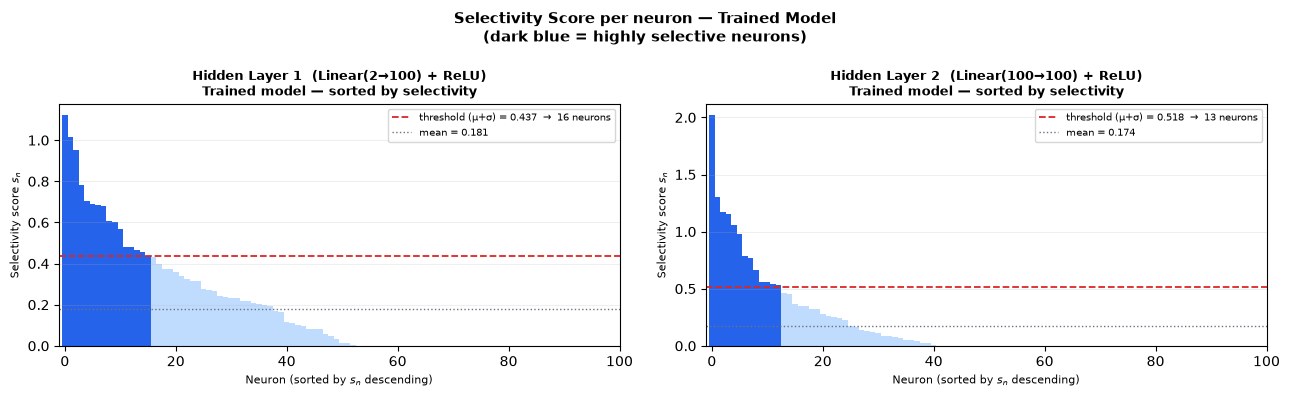

Figure saved to ..\images_VF_v2\xai_selectivity_sorted.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rec = xai_results['trained']
for ax, layer in zip(axes, LAYER_NAMES):
    s      = rec['scores'][layer]
    sorted_s = np.sort(s)[::-1]  # descendente
    n_neurons = len(s)
    threshold = s.mean() + s.std()  # neuronas "muy selectivas" (>1σ)
    n_high = (s >= threshold).sum()

    bar_colors = ['#2563EB' if v >= threshold else '#BFDBFE' for v in sorted_s]
    ax.bar(range(n_neurons), sorted_s, color=bar_colors, width=1.0, edgecolor='none')
    ax.axhline(threshold, color='#DC2626', lw=1.3, ls='--',
               label=f'threshold (μ+σ) = {threshold:.3f}  →  {n_high} neurons')
    ax.axhline(s.mean(), color='#6B7280', lw=1.0, ls=':',
               label=f'mean = {s.mean():.3f}')

    ax.set_title(f'{LAYER_LABELS[layer]}\nTrained model — sorted by selectivity',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Neuron (sorted by $s_n$ descending)', fontsize=8)
    ax.set_ylabel('Selectivity score $s_n$', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim(-1, n_neurons)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Selectivity Score per neuron — Trained Model\n'
             '(dark blue = highly selective neurons)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_selectivity_sorted.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_selectivity_sorted.png"}')

## Visualización 3 — Heatmap de activaciones (entrenado vs control)

Cada fila es una neurona (100), cada columna es una condición de preferencia. Se muestra el valor de activación post-ReLU. La diferencia visual entre columnas evidencia la selectividad.

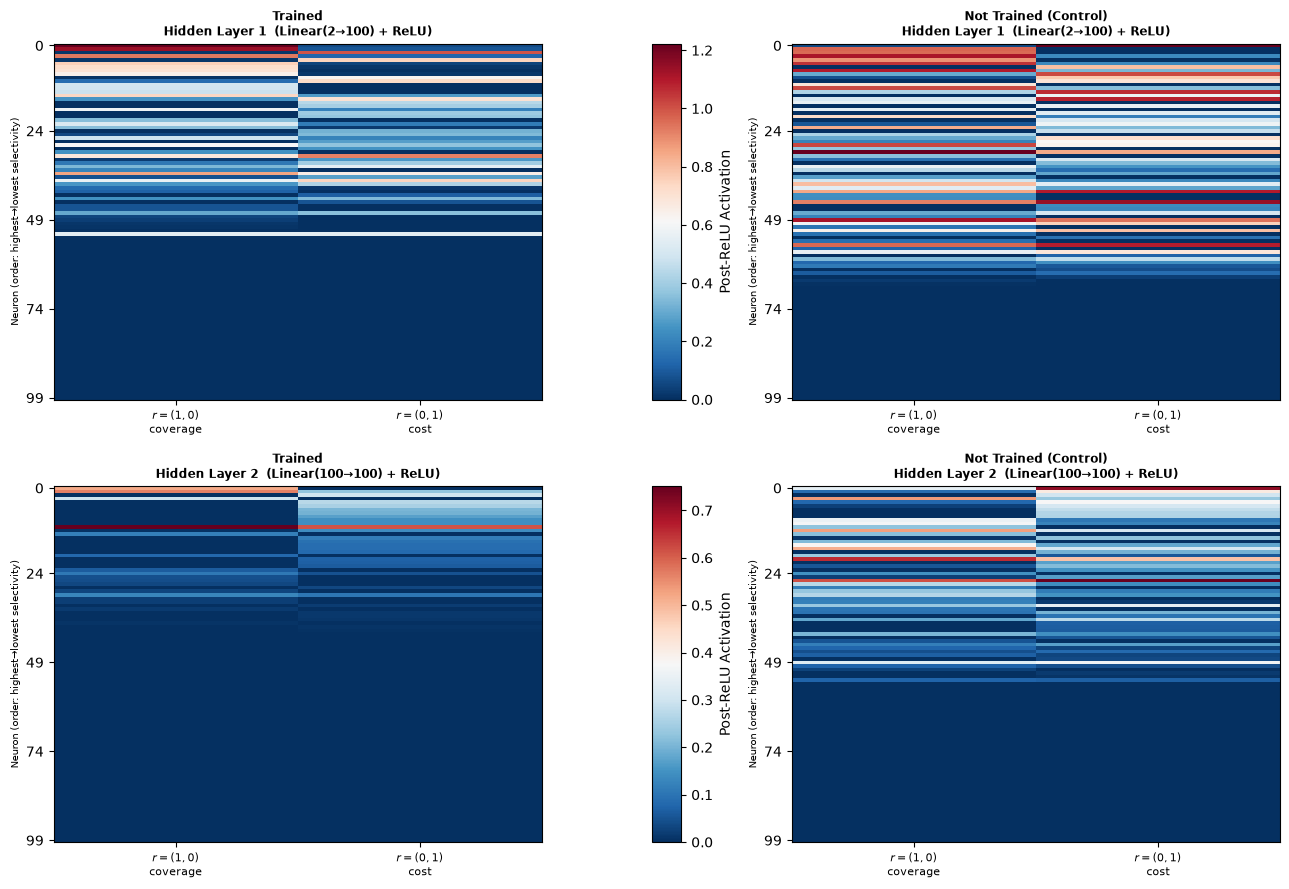

Figure saved to ..\images_VF_v2\xai_heatmap.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9),
                         gridspec_kw={'width_ratios': [1, 0.06, 1]})

for row, layer in enumerate(LAYER_NAMES):
    for col_offset, label in enumerate(('trained', 'no_trained')):
        rec  = xai_results[label]
        v1   = rec['a_cov'][layer]
        v2   = rec['a_cost'][layer]
        data = np.stack([v1, v2], axis=1)
        order = np.argsort(rec['scores'][layer])[::-1]
        data  = data[order]

        ax_col = 0 if col_offset == 0 else 2   # col 0 y col 2
        ax  = axes[row, ax_col]
        im  = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=0)

        label_es = 'Trained' if label == 'trained' else 'Not Trained (Control)'
        ax.set_title(f'{label_es}\n{LAYER_LABELS[layer]}',
                     fontsize=8.5, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['$r=(1,0)$\ncoverage', '$r=(0,1)$\ncost'], fontsize=8)
        ax.set_ylabel('Neuron (order: highest→lowest selectivity)', fontsize=7)
        ax.set_yticks([0, 24, 49, 74, 99])

    # Colorbar en columna 1 (entre los dos heatmaps)
    cb_ax = axes[row, 1]
    fig.colorbar(im, cax=cb_ax, label='Post-ReLU Activation')

#plt.suptitle('Heatmap de activaciones del Hypernetwork\n'
#             'Neuronas ordenadas por selectividad descendente',
#             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_heatmap.png"}')

## Visualización 4 — Comparación Cosine Similarity y % neuronas activas

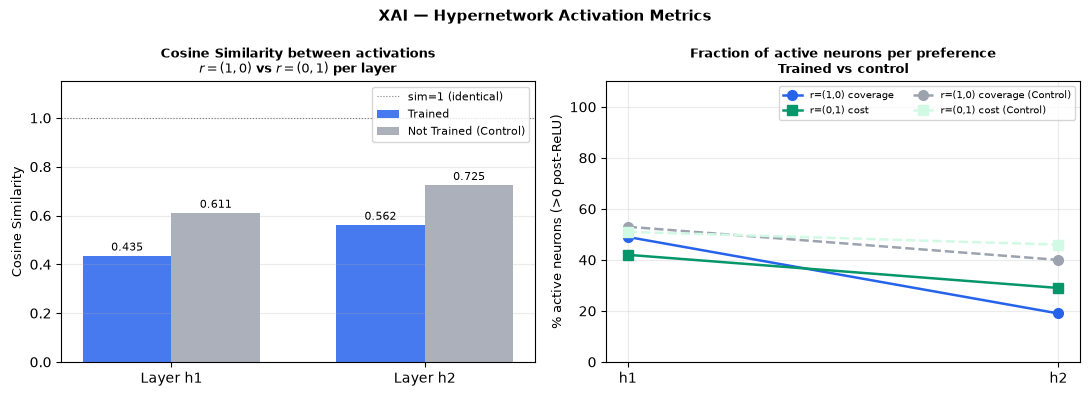

Figure saved to ..\images_VF_v2\xai_cosine_frac.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

layer_ticks = ['h1', 'h2']
x = np.arange(len(layer_ticks))
width = 0.35

# ── Cosine similarity ────────────────────────────────────────────────────────
ax = axes[0]
cos_trained   = [xai_results['trained']['cosine_sim'][l]   for l in layer_ticks]
cos_untrained = [xai_results['no_trained']['cosine_sim'][l] for l in layer_ticks]

bars1 = ax.bar(x - width/2, cos_trained,   width, label='Trained',         color='#2563EB', alpha=0.85)
bars2 = ax.bar(x + width/2, cos_untrained, width, label='Not Trained (Control)',color='#9CA3AF', alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Cosine Similarity', fontsize=9)
ax.set_title('Cosine Similarity between activations\n$r=(1,0)$ vs $r=(0,1)$ per layer',
             fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Layer h1', 'Layer h2'])
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='black', lw=0.8, ls=':', alpha=0.5, label='sim=1 (identical)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis='y')

# ── Fracción de neuronas activas ─────────────────────────────────────────────
ax2 = axes[1]
for offset, (label, color_cov, color_cost, ls) in enumerate([
    ('trained',    '#2563EB', '#059669', '-'),
    ('no_trained', '#9CA3AF', '#D1FAE5', '--'),
]):
    fa  = xai_results[label]['frac_act']
    cov  = [fa[l]['cov']  * 100 for l in layer_ticks]
    cost = [fa[l]['cost'] * 100 for l in layer_ticks]

    suffix = '' if label == 'trained' else ' (Control)'
    ax2.plot(layer_ticks, cov,  'o' + ls, color=color_cov,  lw=1.8, ms=7,
             label=f'r=(1,0) coverage{suffix}')
    ax2.plot(layer_ticks, cost, 's' + ls, color=color_cost, lw=1.8, ms=7,
             label=f'r=(0,1) cost{suffix}')

ax2.set_ylabel('% active neurons (>0 post-ReLU)', fontsize=9)
ax2.set_title('Fraction of active neurons per preference\nTrained vs control',
              fontsize=9, fontweight='bold')
ax2.set_ylim(0, 110)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.25)

plt.suptitle('XAI — Hypernetwork Activation Metrics',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_cosine_frac.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_cosine_frac.png"}')

## Visualización 5 — Variación de activaciones a lo largo de la curva de preferencias

Se barre $r_{cov}$ de 0 a 1 en pasos de 0.05 y se grafica la evolución de la activación media, el % de neuronas activas, y las primeras 10 neuronas más selectivas de h2.

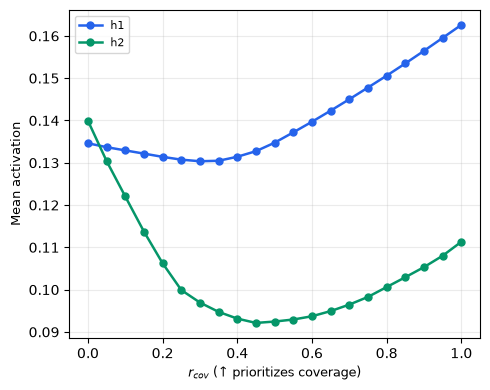

Figure saved to ..\images_VF_v2\xai_sweep_mean.png


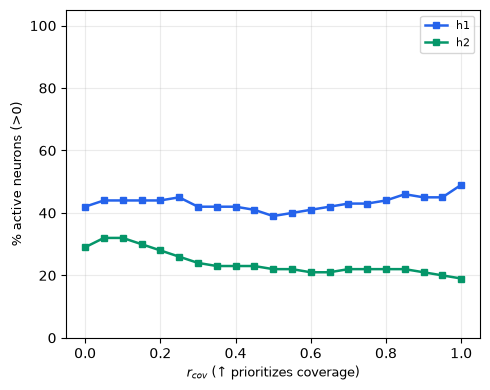

Figure saved to ..\images_VF_v2\xai_sweep_frac.png


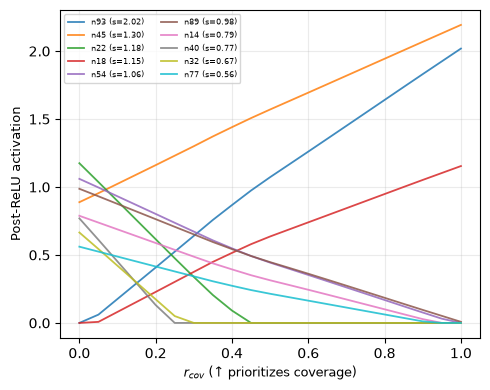

Figure saved to ..\images_VF_v2\xai_sweep_top10.png


In [20]:
SHOW_TITLE = False  # ← toggle: True = show titles, False = no titles

R_SWEEP_XAI = np.linspace(0.0, 1.0, 21)  # 21 points for clear visualization

sweep_acts = {'h1': [], 'h2': []}
for rc in R_SWEEP_XAI:
    r_t = torch.tensor([[rc, 1.0 - rc]], dtype=torch.float32)
    acts = capture_activations(trained_model, r_t)
    for layer in LAYER_NAMES:
        sweep_acts[layer].append(acts[layer])
for layer in LAYER_NAMES:
    sweep_acts[layer] = np.stack(sweep_acts[layer])  # (21, 100)

# Most selective neurons in h2 (by selectivity score of the trained model)
top_k = 10
sel_scores_h2 = xai_results['trained']['scores']['h2']
top_idx_h2    = np.argsort(sel_scores_h2)[::-1][:top_k]

# ── Figure 1: Mean activation per layer ──────────────────────────────────────
fig1, ax = plt.subplots(figsize=(5, 4))
for layer, color in [('h1', '#2563EB'), ('h2', '#059669')]:
    mean_act = sweep_acts[layer].mean(axis=1)
    ax.plot(R_SWEEP_XAI, mean_act, 'o-', color=color, lw=1.8, ms=5, label=layer)
ax.set_xlabel('$r_{cov}$ (↑ prioritizes coverage)', fontsize=9)
ax.set_ylabel('Mean activation', fontsize=9)
if SHOW_TITLE:
    ax.set_title('Mean hypernetwork activation\nas a function of $r_{cov}$',
                 fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_sweep_mean.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_sweep_mean.png"}')

# ── Figure 2: % active neurons per layer ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 4))
for layer, color in [('h1', '#2563EB'), ('h2', '#059669')]:
    frac = (sweep_acts[layer] > 0).mean(axis=1) * 100
    ax2.plot(R_SWEEP_XAI, frac, 's-', color=color, lw=1.8, ms=5, label=layer)
ax2.set_xlabel('$r_{cov}$ (↑ prioritizes coverage)', fontsize=9)
ax2.set_ylabel('% active neurons (>0)', fontsize=9)
if SHOW_TITLE:
    ax2.set_title('Fraction of active neurons\nas a function of $r_{cov}$',
                  fontsize=9, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_sweep_frac.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_sweep_frac.png"}')

# ── Figure 3: Top-k most selective neurons in h2 ─────────────────────────────
fig3, ax3 = plt.subplots(figsize=(5, 4))
cmap = plt.colormaps['tab10']
for i, nidx in enumerate(top_idx_h2):
    ax3.plot(R_SWEEP_XAI, sweep_acts['h2'][:, nidx],
             '-', color=cmap(i), lw=1.3, alpha=0.85,
             label=f'n{nidx} (s={sel_scores_h2[nidx]:.2f})')
ax3.set_xlabel('$r_{cov}$ (↑ prioritizes coverage)', fontsize=9)
ax3.set_ylabel('Post-ReLU activation', fontsize=9)
if SHOW_TITLE:
    ax3.set_title(f'Top-{top_k} most selective neurons (h2)\nevolution with $r$',
                  fontsize=9, fontweight='bold')
ax3.legend(fontsize=6, ncol=2, loc='best')
ax3.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(IMG_DIR / 'xai_sweep_top10.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved to {IMG_DIR / "xai_sweep_top10.png"}')

## Resumen e Interpretación

### Guía para interpretar los resultados

| Indicador | Modelo entrenado esperado | Modelo no entrenado esperado | Implicación |
|-----------|--------------------------|------------------------------|-------------|
| `mean(s_n)` | **Mayor** | Menor | El entrenamiento aumenta la sensibilidad neuronal a la preferencia |
| `max(s_n)`  | **Mayor** | Menor | Hay neuronas que se especializan fuertemente |
| Cosine Similarity | **Menor** (0 → 1) | Mayor (cercana a 1) | Activaciones más distintas entre preferencias extremas |
| % neuronas activas | **Diferente** entre r_cov y r_cost | Similar | Distintas sub-redes se activan para distintas preferencias |

### Conexión con el paper (POCCO / HMOE)

Si el modelo entrenado muestra un `mean(s_n)` significativamente mayor que el no entrenado y una `cosine_sim` menor, esto respalda la hipótesis del paper: el hypernetwork desarrolla **rutas computacionales preferencialmente selectivas** análogas a los expertos especializados de POCCO y HMOE, pero de forma implícita a través de la generación de pesos.

La implicación práctica es que **el pruning dirigido por selectividad** podría reducir el overhead de memoria del PHN (hasta ×100 según la literatura) generando solo los pesos necesarios para el rango de preferencias requerido.

In [19]:
# Tabla de conclusión final
print('='*70)
print('SUMMARY XAI — Preference-Selective Activation Analysis')
print('='*70)
for label in ('trained', 'no_trained'):
    rec = xai_results[label]
    nombre = 'Trained          ' if label == 'trained'    else 'Untrained (ctrl)  '
    print(f'\n  Model: {nombre}')
    for layer in LAYER_NAMES:
        s  = rec['scores'][layer]
        cs = rec['cosine_sim'][layer]
        fa = rec['frac_act'][layer]
        n_high = int((s >= s.mean() + s.std()).sum())
        print(f'    {LAYER_LABELS[layer]}')
        print(f'      mean(s_n)={s.mean():.4f}  max(s_n)={s.max():.4f}  '
              f'n_selective(>μ+σ)={n_high}')
        print(f'      cosine_sim={cs:.4f}  '
              f'%act cov={fa["cov"]:.1%}  %act cost={fa["cost"]:.1%}')

print('\n' + '='*70)
print('Figures generated:')
for fname in ['xai_histogramas.png', 'xai_selectivity_sorted.png',
              'xai_heatmap.png', 'xai_cosine_frac.png', 'xai_sweep.png']:
    print(f'  images/{fname}')


SUMMARY XAI — Preference-Selective Activation Analysis

  Model: Trained          
    Hidden Layer 1  (Linear(2→100) + ReLU)
      mean(s_n)=0.1813  max(s_n)=1.1211  n_selective(>μ+σ)=16
      cosine_sim=0.4355  %act cov=49.0%  %act cost=42.0%
    Hidden Layer 2  (Linear(100→100) + ReLU)
      mean(s_n)=0.1735  max(s_n)=2.0187  n_selective(>μ+σ)=13
      cosine_sim=0.5619  %act cov=19.0%  %act cost=29.0%

  Model: Untrained (ctrl)  
    Hidden Layer 1  (Linear(2→100) + ReLU)
      mean(s_n)=0.2651  max(s_n)=1.1609  n_selective(>μ+σ)=19
      cosine_sim=0.6110  %act cov=53.0%  %act cost=51.0%
    Hidden Layer 2  (Linear(100→100) + ReLU)
      mean(s_n)=0.0802  max(s_n)=0.3679  n_selective(>μ+σ)=19
      cosine_sim=0.7249  %act cov=40.0%  %act cost=46.0%

Figures generated:
  images/xai_histogramas.png
  images/xai_selectivity_sorted.png
  images/xai_heatmap.png
  images/xai_cosine_frac.png
  images/xai_sweep.png
